## Population genetic analysis of microsatellites

In [1]:
import os
import glob
import pandas as pd
pd.options.mode.chained_assignment = None
import numpy as np
import scipy.stats as ss
from itertools import product
from dataclasses import dataclass

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.colors import ListedColormap
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, leaves_list

### Settings

In [2]:
FOCUS_PROVINCES = ['western', 'northwestern'] # focus on these for this analysis
W = 3.4 # roughly width of one column
save_results = True
output_dir = "../figures/fig2/popgen"
os.makedirs(output_dir, exist_ok=True)

## Load data

In [3]:
df_microsats = (
    pd.read_csv("../figures/fig2/cleaning/table.microsat_data.alleles_called.no_eastern.csv")
    .query("province in @FOCUS_PROVINCES")x
)

# quickly get sample information
df_samples = df_microsats[["sample_id", "extraction_id", "set_type", "province", "district", "carrier_A724E"]].drop_duplicates()
df_samples.index = df_samples.sample_id

In [4]:
pd.crosstab(
    df_samples["province"],
    df_samples["carrier_A724E"],
    margins='All'
)

carrier_A724E,False,True,All
province,,,
northwestern,31,22,53
western,42,25,67
All,73,47,120


## Visualise as a heatmap

#### Functions

In [5]:
def relabel_microsats_to_freq_rankorder(arr: pd.DataFrame) -> pd.DataFrame:
    """
    Relabel an array of microsatellite alleles (in bp) to their RANK ORDER
    per allele
    """
    arr_rankorder = arr.copy()
    for c in arr.columns:
        #alleles = df_pivot[c].unique()
        alleles = arr[c].value_counts().index
        arr_rankorder[c] = arr_rankorder[c].map(dict(zip(alleles, range(len(alleles)))))
    return arr_rankorder

#### Prepare the data

In [6]:
arr_microsats = pd.pivot_table(
    index="sample_id",
    columns="microsat_kbp",
    values="allele_size",
    data=df_microsats
)

In [7]:
arr_microsats.head()

microsat_kbp,-31.90,-6.36,-3.70,-0.15,15.00,31.00,72.30
sample_id,,,,,,,
1012412,200.0,256.0,153.0,213.0,138.0,294.0,231.0
1012423,210.0,274.0,161.0,191.0,135.0,303.0,241.0
1012426,200.0,256.0,153.0,217.0,135.0,294.0,227.0
1012427,198.0,271.0,151.0,191.0,132.0,303.0,229.0
1012431,204.0,271.0,161.0,201.0,135.0,303.0,235.0


In [8]:
# Create the array
arr_rankorder = relabel_microsats_to_freq_rankorder(arr_microsats)

# Cluster
pdist_condensed = pdist(arr_rankorder, metric='hamming') # compute hamming distance between
Z = linkage(pdist_condensed, method='average')#, optimal_ordering=True) # hierarchical cluster
order = leaves_list(Z) # get the indices
arr_rankorder = arr_rankorder.iloc[order] # here we reorder based on clustering

# Insert a A724E column
a724e_encoding = [-2 if df_samples.loc[i]['carrier_A724E'] else -1 for i in arr_rankorder.index]
arr_rankorder.insert(4, "A724E", a724e_encoding)

**Prepare province annotation**

In [9]:
province_map = {"western": 1, "northwestern": 2}
arr_provinces = np.array(
    [province_map[df_samples.loc[i]['province']] for i in arr_rankorder.index]
)[:, np.newaxis]

**Prepare color schemes**

In [10]:
COLS = sns.color_palette("Spectral", 10)
COLS

[(0.8141484044598232, 0.2196847366397539, 0.3048058439061899),
 (0.9330257593233372, 0.3913110342176086, 0.27197231833910035),
 (0.9817762399077278, 0.6073817762399076, 0.3457900807381776),
 (0.9946943483275663, 0.8092272202998846, 0.48696655132641287),
 (0.9982314494425221, 0.9451749327181853, 0.6570549788542868),
 (0.9557862360630527, 0.9823144944252211, 0.6800461361014996),
 (0.8202998846597465, 0.9275663206459055, 0.6126874279123413),
 (0.5910034602076126, 0.835524798154556, 0.6442906574394464),
 (0.3600153787004998, 0.7161860822760476, 0.6655132641291811),
 (0.21299500192233756, 0.5114186851211072, 0.730795847750865)]

In [11]:
n_alleles_max = arr_rankorder.max().max()
a724_cols = [COLS[0], (1,1,1)]#['darkorange', 'white']
most_common_allele_col = [COLS[-1]]#['steelblue']

offset = 20 # start internal for shading purposes
other_alleles = sns.color_palette("Greys_r", n_alleles_max + offset)[offset:]
allele_cmap = ListedColormap(
    a724_cols + most_common_allele_col + other_alleles
)

# Provinces
CP = [COLS[2], COLS[-2]]#["#59A14F", "#7B6BAF"]
province_cols = {p: c for p, c in zip(province_map, CP)}
province_cmap = ListedColormap(province_cols.values())

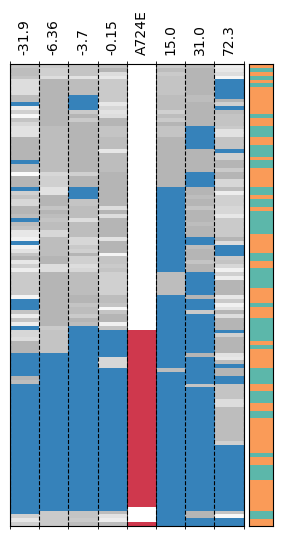

In [12]:
fig = plt.figure(figsize=(W, 6))

gs = GridSpec(ncols=9, nrows=1)
axh = fig.add_subplot(gs[:, :8])
axa = fig.add_subplot(gs[8])

# Microsatellites
# ---------------
n_samples, n_markers = arr_rankorder.shape
axh.matshow(arr_rankorder, 
            cmap=allele_cmap,
            aspect='auto')

# Set the ticks
axh.set_xticks(range(n_markers), arr_rankorder.columns)
axh.set_yticks(range(n_samples))

# Add a custom minor grid
axh.xaxis.set_minor_locator(plt.MultipleLocator(0.5))
axh.grid(axis='x', which='minor', ls='dashed', color='black')

axh.tick_params(axis='x', rotation=90, top=False, bottom=False)
axh.tick_params(axis='y', labelleft=False, tick1On=False)

# Delineate A724E
if True:
    _x = arr_rankorder.columns.tolist().index('A724E')
    axh.axvline(_x - 0.5, color='black', lw=0.5)
    axh.axvline(_x + 0.5, color='black', lw=0.5)

# Province Annotation
# -------------------
axa.pcolormesh(arr_provinces,
               cmap=province_cmap)
axa.tick_params(
    axis='both',
    which='both',
    bottom=False, top=False,
    left=False, right=False,
    labelbottom=False, labelleft=False
)

if save_results:
    fig.savefig(f"{output_dir}/plot.microsat_heatmap.pdf", dpi=600, bbox_inches="tight", pad_inches=0.5)
    fig.savefig(f"{output_dir}/plot.microsat_heatmap.png", dpi=600, bbox_inches="tight", pad_inches=0.5)

## Heterozygosity and other diversity statistics

These should go into tables

##### Mean across markers
- Compute the mean heterozygosity across all 7 markers
  - For 724A
  - For 724E
- And compute the difference between the two groups
- Then
  - Randomly sample equal size groups without replacement, and repeat the above process to compute het_mean_diff
  - Use this distribution to compute a p-value

In [13]:
df_microsats[['microsat_kbp', 'province', 'carrier_A724E', 'allele_size']] # here is the key information

,microsat_kbp,province,carrier_A724E,allele_size
0,-0.15,northwestern,True,217.0
1,-0.15,northwestern,False,221.0
2,-0.15,northwestern,False,191.0
3,-0.15,western,True,213.0
4,-0.15,western,False,189.0
...,...,...,...,...
849,-6.36,northwestern,True,256.0
850,-6.36,northwestern,False,271.0
851,-6.36,northwestern,False,271.0
852,-6.36,western,False,271.0


In [14]:
# likely I can do all the tests (individual, and mean) in a single round of permutation
# first let's build the code to compute for each case

In [15]:
def calc_unbiased_het(alleles: pd.Series) -> tuple[int, float]:
    """Calculate expected heterozygosity in an unbiased fashion"""
    n = alleles.shape[0]
    freqs = alleles.value_counts() / n
    return n, n / (n - 1) * (1 - (freqs**2).sum())

In [16]:
@dataclass
class HResult:
    province: str
    marker: str
    n_wt: int
    het_wt: float
    n_carrier: int
    het_carrier: float
    het_delta: float = None
    permutation: int = None
    def __post_init__(self):
        self.het_delta = self.het_wt - self.het_carrier

In [17]:
def collapse_to_mean_het_across_markers(df: pd.DataFrame, groupby: list[str] = ["province", "n_wt", "n_carrier"]) -> pd.DataFrame:
    df_permutations_mean = (df
    .groupby(groupby)
    .agg(
        het_wt_mean = pd.NamedAgg("het_wt", "mean"),
        het_carrier_mean = pd.NamedAgg("het_carrier", "mean")
        )
        .reset_index()
       )
    df_permutations_mean["het_delta"] = df_permutations_mean["het_wt_mean"] - df_permutations_mean["het_carrier_mean"]
    return df_permutations_mean

In [18]:
provinces = ['northwestern', 'western', 'both']
results = []
for province in provinces:
    if province == 'both':
        pdf = df_microsats
    else:
        pdf = df_microsats.query("province == @province")
    for marker, mdf in pdf.groupby("microsat_kbp"):
        mdf_wt = mdf.query("~carrier_A724E")
        mdf_carrier = mdf.query("carrier_A724E")
        
        n_wt, het_wt = calc_unbiased_het(mdf_wt['allele_size'])
        n_carrier, het_carrier = calc_unbiased_het(mdf_carrier['allele_size'])

        # store
        results.append(HResult(
            province=province,
            marker=marker,
            n_wt=n_wt,
            het_wt=het_wt,
            n_carrier=n_carrier,
            het_carrier=het_carrier,
        ))

# Combine and take mean across markers
df_het = pd.DataFrame(results) 
df_het_mean = collapse_to_mean_het_across_markers(df_het)

In [19]:
# Permutation
n_permutations = 1_000
results_permut = []
for province in provinces:
    if province == 'both':
        pdf = df_microsats
    else:
        pdf = df_microsats.query("province == @province")
    for ix in range(n_permutations):
        
        for marker, mdf in pdf.groupby("microsat_kbp"):
            
            # compute number of WT and carriers
            n_carrier = mdf.carrier_A724E.sum()
            n_wt = mdf.shape[0] - n_carrier

            # randomly sample
            mdf_wt = mdf.sample(n=n_wt, replace=False)
            _wt_samples = mdf_wt.sample_id.tolist()
            mdf_carrier = mdf.query("sample_id not in @_wt_samples")

            # compute statitics
            n_wt, het_wt = calc_unbiased_het(mdf_wt['allele_size'])
            n_carrier, het_carrier = calc_unbiased_het(mdf_carrier['allele_size'])
    
            # store
            results_permut.append(HResult(
                province=province,
                marker=marker,
                n_wt=n_wt,
                het_wt=het_wt,
                n_carrier=n_carrier,
                het_carrier=het_carrier,
                permutation=ix
            ))

In [20]:
# data frames
df_permut = pd.DataFrame(results_permut)
df_permut_mean = collapse_to_mean_het_across_markers(pd.DataFrame(results_permut), groupby=["province", "permutation", "n_wt", "n_carrier"])

<Axes: xlabel='province', ylabel='het_delta'>

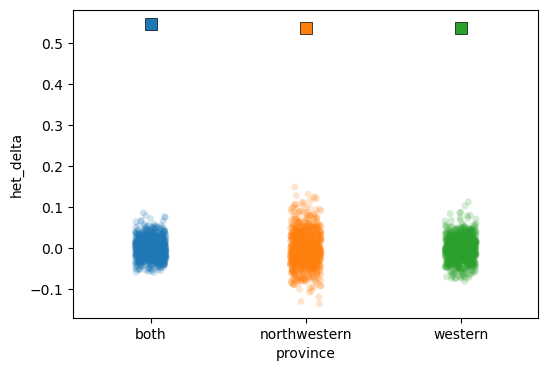

In [21]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

sns.stripplot(
    x="province",
    y="het_delta",
    hue="province",
    #dodge=True,
    legend=False,
    alpha=0.2,
    data=df_permut_mean)

sns.stripplot(
    x="province",
    y="het_delta",
    hue="province",
    edgecolor='black',
    linewidth=0.5,
    marker='s',
    size=8,
    data=df_het_mean,
)   

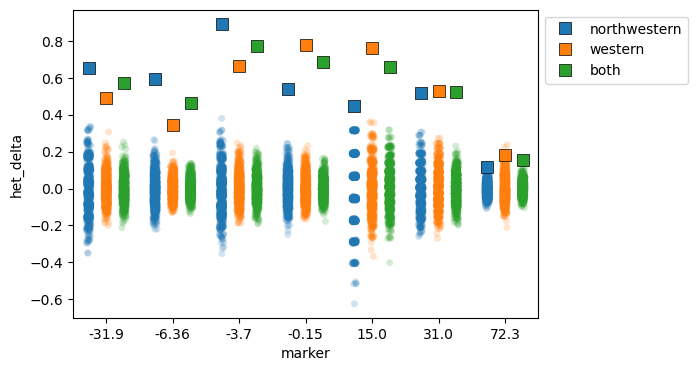

In [22]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

sns.stripplot(
    x="marker",
    y="het_delta",
    hue="province",
    dodge=True,
    legend=False,
    alpha=0.2,
    data=df_permut,
    ax=ax)

sns.stripplot(
    x="marker",
    y="het_delta",
    hue="province",
    dodge=True,
    data=df_het,
    edgecolor='black',
    linewidth=0.5,
    marker='s',
    size=8,
    ax=ax
) 

ax.legend(bbox_to_anchor=(1,1), loc="upper left")

- So the p-values are very close to zero; but note that the smallest P-value I could actually report is one over the number of iterations

In [23]:
pvalues = []
for _, row in df_het_mean.iterrows():
    province = row['province']
    vals = df_permut_mean.query("province == @province")['het_delta']
    pvalue = (vals >= row['het_delta']).sum()/vals.shape[0]
    pvalues.append(pvalue)
df_het_mean["pvalue_permut"] = pvalues

In [24]:
pvalues = []
for _, row in df_het.iterrows():
    province, marker = row[['province', 'marker']]
    vals = df_permut.query("province == @province and marker == @marker")['het_delta']
    pvalue = (vals >= row['het_delta']).sum()/vals.shape[0]
    pvalues.append(pvalue)
df_het["pvalue_permut"] = pvalues

### Write heterozygosity tables

In [25]:
em_dash = "—"
het_sym = "Hₑ"
delta = "Δ"

In [26]:
column_names = {
    "province": "Province",
    "marker":  f"Locus {em_dash} kbp",
    "n_wt": f"724A {em_dash} N",
    "n_wt_mean": f"724A {em_dash} N",
    "het_wt": f"724A {em_dash} {het_sym}",
    "het_wt_mean": f"724A {em_dash} {het_sym}",
    "n_carrier": f"724E {em_dash} N",
    "n_carrier_mean": f"724E {em_dash} N",
    "het_carrier": f"724E {em_dash} {het_sym}",
    "het_carrier_mean": f"724E {em_dash} {het_sym}",
    "het_delta": f"{delta}{het_sym}",
    "het_delta_mean": f"{delta}{het_sym}",
    "pvalue_permut": "P Value"
}

In [27]:
def pvalue_for_table(p: float) -> str:
    if p < 0.001:
        return '<.001'
    return str(p)[1:]

In [28]:
_df_het = df_het[[c for c in df_het.columns if c in column_names]].rename(column_names, axis=1)
_df_het['P Value'] = _df_het['P Value'].apply(pvalue_for_table)
_df_het['Province'] = _df_het['Province'].str.capitalize()
_df_het = _df_het.round(2)

In [29]:
_df_het_mean = df_het_mean[[c for c in df_het_mean.columns if c in column_names]].rename(column_names, axis=1)
_df_het_mean['P Value'] = _df_het_mean['P Value'].apply(pvalue_for_table)
_df_het_mean['Province'] = _df_het_mean['Province'].str.capitalize()
_df_het_mean = _df_het_mean.round(2)

In [30]:
if save_results:
    _df_het.to_excel("../tables/stable_microsat-het-markers.xlsx", index=False)
    _df_het_mean.to_excel("../tables/stable_microsat-het-mean.xlsx", index=False)

## Haplotype statistics
- Focus on -31.90 to 31.00

In [31]:
def create_haplotype_count_table(arr: pd.DataFrame) -> pd.DataFrame:
    """Create a table counting haplotypes and computing their frequencies"""
    arr_haps = arr.value_counts().reset_index()
    arr_haps["N"] = arr_haps["count"].sum()
    arr_haps["freq"] = arr_haps["count"] / arr_haps["N"]
    return arr_haps

In [32]:
arr_microsats_core = arr_microsats.drop(72.30, axis=1)
arr_microsats_core.head()

microsat_kbp,-31.90,-6.36,-3.70,-0.15,15.00,31.00
sample_id,,,,,,
1012412,200.0,256.0,153.0,213.0,138.0,294.0
1012423,210.0,274.0,161.0,191.0,135.0,303.0
1012426,200.0,256.0,153.0,217.0,135.0,294.0
1012427,198.0,271.0,151.0,191.0,132.0,303.0
1012431,204.0,271.0,161.0,201.0,135.0,303.0


In [33]:
samples_carrier = df_samples.query("carrier_A724E").sample_id.tolist()
samples_wt = df_samples.query("~carrier_A724E").sample_id.tolist()

In [34]:
arr_haps_carrier = create_haplotype_count_table(arr_microsats_core.loc[samples_carrier])
arr_haps_wt = create_haplotype_count_table(arr_microsats_core.loc[samples_wt])

In [35]:
arr_haps_carrier.head()

,-31.9,-6.36,-3.7,-0.15,15.0,31.0,count,N,freq
0,200.0,256.0,153.0,213.0,135.0,294.0,32,47,0.680851
1,200.0,256.0,153.0,217.0,135.0,294.0,3,47,0.063830
2,204.0,268.0,153.0,213.0,135.0,294.0,3,47,0.063830
3,214.0,268.0,153.0,213.0,135.0,294.0,2,47,0.042553
4,190.0,268.0,153.0,213.0,135.0,294.0,1,47,0.021277


In [36]:
arr_haps_wt.head()

,-31.9,-6.36,-3.7,-0.15,15.0,31.0,count,N,freq
0,212.0,271.0,149.0,189.0,138.0,294.0,6,73,0.082192
1,190.0,271.0,149.0,199.0,129.0,303.0,4,73,0.054795
2,204.0,280.0,147.0,191.0,141.0,294.0,3,73,0.041096
3,210.0,274.0,147.0,201.0,129.0,294.0,3,73,0.041096
4,204.0,274.0,147.0,205.0,141.0,294.0,3,73,0.041096


In [37]:
common_hap = arr_microsats_core.loc[samples_carrier].value_counts().index[0]

In [38]:
arr_hap_annot = pd.concat([df_samples, arr_microsats_core], axis=1)

In [39]:
arr_hap_annot["is_common"] = (arr_microsats_core == common_hap).all(1)

In [40]:
pd.crosstab(
    [arr_hap_annot["province"], arr_hap_annot['carrier_A724E']],
    arr_hap_annot["is_common"],
    margins='both'
).reset_index()

is_common,province,carrier_A724E,False,True,All
0,northwestern,False,31,0,31
1,northwestern,True,8,14,22
2,western,False,41,1,42
3,western,True,7,18,25
4,All,,87,33,120


- 14/22 carriers are common in NW
- 18/25 are common in W

In [41]:
14/22, 18/25

(0.6363636363636364, 0.72)